# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [2]:
medical.shape

(1338, 8)

In [3]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__
The mean (13,270) and standard deviation (12,110) are mathematically correct but are not ideal for describing this dataset.

**Right-Skewed Distribution:** The histogram shows a heavy "tail" to the right, meaning a small number of patients have extremely high charges (up to $63,770)

**Mean vs. Median:** Because of this skew, the mean is significantly higher than the median ($9,382). The mean is being "pulled" upward by outliers and does not represent the "typical" patient experience.

**High Variability:** The standard deviation is nearly as large as the mean itself, indicating that the data is very spread out and does not follow a normal (bell-shaped) distribution.


In [4]:
medical.charges.describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

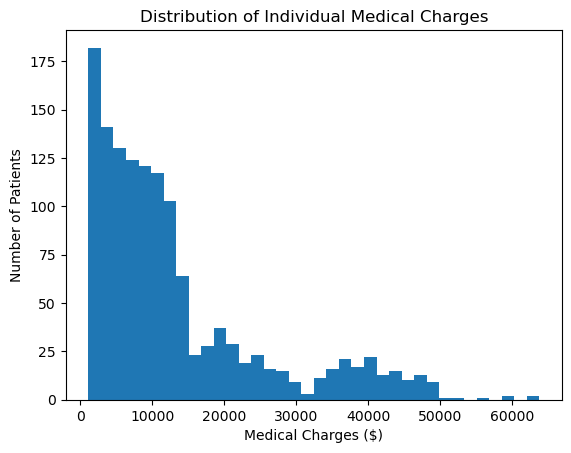

In [5]:
Bin = int(np.sqrt(len(medical.charges)))
_ = plt.hist(medical.charges, bins = Bin)
_ = plt.xlabel('Medical Charges ($)')
_ = plt.ylabel('Number of Patients')
_ = plt.title('Distribution of Individual Medical Charges')
_ = plt.show()

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__
If the dataset represents a **random sample of medical charges**, it can be used to make statistical inferences about the **true population mean charge**. Since the sample size is large (n = 1338), the **Central Limit Theorem** implies that the sampling distribution of the sample mean will be approximately normal, even though the distribution of charges is right-skewed. This allows us to apply standard statistical inference methods.

The most appropriate frequentist test is a **one-sample t-test**, since we are testing a claim about the **population mean** and the **population standard deviation is unknown**.

The hypotheses would be:

- **H₀:** μ = 12000  
- **H₁:** μ < 12000  

This is a **one-sided (left-tailed) test** because the administrator is concerned that the average charge has **fallen below $12,000**.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__

**Appropriate Confidence Interval**

Because the administrator is concerned that the true mean charge has **fallen below \$12,000**, the appropriate interval is a **one-sided 95% confidence interval (lower bound)**.

**Calculation**

Sample statistics:  
- \( n = 1338 \)  
- \( \bar{x} = 13270.42 \)  
- \( s = 12110.01 \)

Standard Error:
\[
SE = \frac{s}{\sqrt{n}} \approx \frac{12110.01}{\sqrt{1338}} \approx 331.07
\]

Critical value for a one-sided 95% interval with \( df = 1337 \):
\[
t_{0.95,1337} \approx 1.646
\]

Lower confidence bound:
\[
L = \bar{x} - t \times SE = 13270.42 - (1.646 \times 331.07) \approx 12725.49
\]

Thus the **95% one-sided confidence interval** is:

\[
(12725.49,\ \infty)
\]

**Conclusion**

Since the lower bound (\$12,725.49) is **greater than \$12,000**, there is **no statistical evidence that the true mean charge has fallen below \$12,000**. Therefore, the administrator should **not be concerned** based on these data.

In [6]:
n = 1338
xbar = 13270.422265
s = 12110.011237
df = n - 1
se = s / np.sqrt(n)

# one-sided 95% lower bound critical value
t_crit = t.ppf(0.95, df)

L = xbar - t_crit * se

print(f"t_crit (one-sided 95%): {t_crit:.6f}")
print(f"95% lower bound for mean: ${L:,.2f}")

t_crit (one-sided 95%): 1.645994
95% lower bound for mean: $12,725.49


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__

In [7]:
insured = medical.charges[medical.insuranceclaim == 1]
uninsured = medical.charges[medical.insuranceclaim ==0]

print(f"Insured Group Size: {len(insured)}")
print(f"Uninsured Group Size: {len(uninsured)}")

Insured Group Size: 783
Uninsured Group Size: 555


In [8]:
insured_len = len(insured)
uninsured_len = len(uninsured)
insured_mean = np.mean(insured)
uninsured_mean = np.mean(uninsured)
insured_std = np.std(insured, ddof = 1)
uninsured_std = np.std(uninsured, ddof=1)

# 2. Calculate Pooled Standard Deviation (sp)
numerator = ((uninsured_len - 1) * uninsured_std**2) + ((insured_len - 1) * insured_std**2)
denominator = insured_len + uninsured_len - 2
sp = np.sqrt(numerator / denominator)

# 3. Calculate t-statistic
t_stat = (uninsured_mean - insured_mean) / (sp * np.sqrt((1/uninsured_len) + (1/insured_len)))

print(f"Pooled Std Dev (sp): {sp:.4f}")
print(f"t-statistic:         {t_stat:.4f}")

Pooled Std Dev (sp): 11520.0343
t-statistic:         -11.8933


__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [9]:
t_stat_scipy, p_val_scipy = stats.ttest_ind(uninsured, insured, equal_var=True)

print(f"SciPy t-statistic: {t_stat_scipy:.4f}")
print(f"SciPy p-value:     {p_val_scipy:.4e}")

SciPy t-statistic: -11.8933
SciPy p-value:     4.4612e-31


In [10]:
# Two-tailed p-value
p_val_manual = 2 * t.sf(np.abs(t_stat), denominator)
print(f"Manual P-value: {p_val_manual}")

Manual P-value: 4.4612302316205886e-31


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__
**Is there a z-test function in `scipy.stats`?**

When I look through the documentation for `scipy.stats`, I see dedicated functions for **t-tests** such as `ttest_1samp`, `ttest_ind`, and `ttest_rel`, but there is no corresponding built-in function for performing a one-sample or two-sample **z-test** directly.

SciPy does provide `scipy.stats.zscore`, but this only standardizes data (subtracts the mean and divides by the standard deviation) and does **not** perform a hypothesis test or return a p-value. In practice, if a z-test is needed, it is usually implemented manually by computing the z-statistic and then using the normal distribution functions (e.g., CDF or survival function) to obtain the p-value, or by using other libraries such as `statsmodels` that provide a `ztest` function.

So, the short answer is: `scipy.stats` does not offer a direct “z-test” function analogous to its t-test functions; you must either code the z-test yourself using normal distribution utilities or use another library.


## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test